**GROUP NUMBER** :                                     37

**FULL NAME**:                                       

**DATASET**:                                          TELCO CUSTOMER CHURN

**DEPTH TRACK**:

**TEAM MEMBERS**:
BALOGUN BUKUNMI P.
LAWRENCE GLORIA C.
ADEFEMI ADELUGBA

**FINAL MODEL:**

**STRATIFIED DUMMY F1/ROC AUC:**

**FINAL MODEL F1/ROC AUC**:

**LEAKAGE COLUMNS DROPPED:**

**FULL RUN TIME ON COLAB:**

## Part 1. Data Foundation

**STEP 1A**: LOAD THE DATASET FROM KAGGLE INSIDE THE NOTEBOOK.

In [1]:
#INSATLLING KAGGLEHUB
!pip install kagglehub

'C:\Users\EHU_HEALTH_TECHNICAL\AppData\Local\Programs\Python\Python314\Scripts\pip.exe' was blocked by your organization's Device Guard policy.
Contact your support person for more info.


In [2]:
#GETTING AUTHENTICATION FROM KAGGLEHUB
import kagglehub
kagglehub.login()

In [3]:
#DOWNLOADING THE DATASET.
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Dataset downloaded to:", path)

Dataset downloaded to: C:\Users\EHU_HEALTH_TECHNICAL\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [4]:
#KNOWING THE FILE NAME.
import os
print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [5]:
#LOADING THE DATASET
import pandas as pd
file_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(file_path)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**STEP 1B**: PUSH OUR DATA INTO SQLITE.

In [6]:
#importing sqlite.
import sqlite3

In [7]:
#creating a connection to a sqlite database
conn = sqlite3.connect("telco_churn.db")

In [8]:
#putting our dataframe into sqlite and name it customers
df.to_sql("customers", conn, if_exists="replace", index=False)

7043

**STEP 2:** RUNNING THREE SQL QUERIES THAT REVEAL SOMETHING USEFUL FOLLOWED BY A MARKDOWN CELL EXPLAINING WHAT WE LEARNT.

In [9]:
#QUERY 1 : HOW MANY CUSTOMERS CHURNED?
# Count customers in each churn category
query1 = """
SELECT Churn, COUNT(*) AS customer_count
FROM customers
GROUP BY Churn;
"""
result1 = pd.read_sql_query(query1, conn)
print(result1)

  Churn  customer_count
0    No            5174
1   Yes            1869


**SQL QUERY 1: MARKDOWN EXPLANATION CELL:**

The query shows that 5,174 customers did not churn, while 1,869 customers churned. This means that approximately 73.5% of customers stayed with the company, while approximately 26.5% left. The target variable is therefore not evenly distributed, which is important because we will need to consider class imbalance when building our classification models later in the project.


In [10]:
# QUERY 2: DOES THE TYPE OF CONTRACT APPEAR TO BE RELATED TO CUSTOMER CHURN?
query2 = """
SELECT
    Contract,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate_pct
FROM customers
GROUP BY Contract
ORDER BY churn_rate_pct DESC;
"""

result2 = pd.read_sql_query(query2, conn)
result2

,Contract,total_customers,churned_customers,churn_rate_pct
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


**SQL QUERY 2 :MARKDOWN EXPLANATION CELL**:

**calculating the churn percentage within each contract type**,

month-to-month = 2220 + 1655 =3875

one year = 1307 + 166 = 1473

two year = 1647 + 48 = 1695

**percentage =**

month-to-month = 1655/3875 = 42.7%

one year = 166/1473 = 11.3%

two year = 48/1695 = 2.8%

The results show a clear difference in customer churn across contract types. Among month-to-month customers, 1,655 out of 3,875 customers churned, which is approximately 42.7%. For one-year contracts, 166 out of 1,473 customers churned, approximately 11.3%. For two-year contracts, only 48 out of 1,695 customers churned, approximately 2.8%.

This suggests that contract type is strongly associated with customer churn in this dataset. Month-to-month customers have a much higher observed churn rate than customers with one-year or two-year contracts. We will investigate this relationship further during exploratory data analysis and model building.


In [11]:
## query 3:CHURN + REVENUE EXPOSURE:WHICH CUSTOMER SEGMENTS HAS BOTH HIGH CHURN AND HIGH MONTHLY REVENUE AT RISK?
query3 = """
SELECT
    Contract,
    InternetService,
    COUNT(*) AS customer_count,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate_pct,
    ROUND(SUM(CASE WHEN Churn = 'Yes' THEN MonthlyCharges ELSE 0 END), 2)
        AS churned_customers_monthly_charges
FROM customers
GROUP BY Contract, InternetService
HAVING COUNT(*) >= 50
ORDER BY churned_customers_monthly_charges DESC;
"""

result3 = pd.read_sql_query(query3, conn)

result3

,Contract,InternetService,customer_count,churned_customers,churn_rate_pct,churned_customers_monthly_charges
0,Month-to-month,Fiber optic,2128,1162,54.61,100482.00
1,Month-to-month,DSL,1223,394,32.22,18367.25
2,One year,Fiber optic,539,104,19.29,10571.95
3,One year,DSL,570,53,9.30,3356.25
4,Two year,Fiber optic,429,31,7.23,3246.10
5,Month-to-month,No,524,99,18.89,1997.85
6,Two year,DSL,628,12,1.91,805.70
7,One year,No,364,9,2.47,190.25
8,Two year,No,638,5,0.78,113.50


**SQL QUERY 3: MARKDOWN EXPLANATION CELL:**

This query combines contract type and internet service to identify customer segments with both high churn and potential monthly revenue exposure.

The month-to-month fiber-optic segment stands out in the results. It contains 2,128 customers, of whom 1,162 churned, giving an observed churn rate of 54.61%. The monthly charges associated with these churned customers total 100,482.

This shows why looking at churn rate alone may not be enough for a business. A customer segment can have a high churn rate, but the potential financial impact also depends on the number of customers and their monthly charges. The results therefore give us a useful business perspective that we can investigate further during the exploratory analysis and classification stages.


**STEP 3:** **PERFORM EDA**(**EXPLORATORY DATA ANALYSIS**)
  

*   SHAPE
*  TYPES


*  MISSING VALUES
*  TARGET DISTRIBUTION


*  THREE TO FIVE FEATURE DISTRIBUTION







In [12]:
# SHAPE : 7043 ROWS AND 21 COLUMNS.
df.shape

(7043, 21)

In [13]:
# TYPES
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [14]:
# MISSING VALUES
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
# TARGET DISTRIBUTION.
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

THREE- FIVE FEATURE DISTRIBUTIONS

1. tenure             -      how long customers have stayed.
2. monthly charges     -      what customers are charged monthly.
3. contract           -      customer's contract type.
4. internet service-         customers internet service type







In [16]:
# TENURE
df["tenure"].describe()


count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

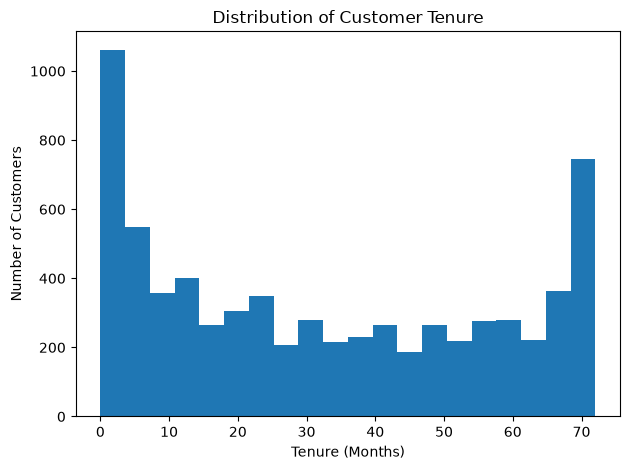

In [17]:
# DISTRIUTION CHART FOR TENURE
import matplotlib.pyplot as plt

plt.hist(df["tenure"], bins=20)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [18]:
# MONTHLYCHARGES
df["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

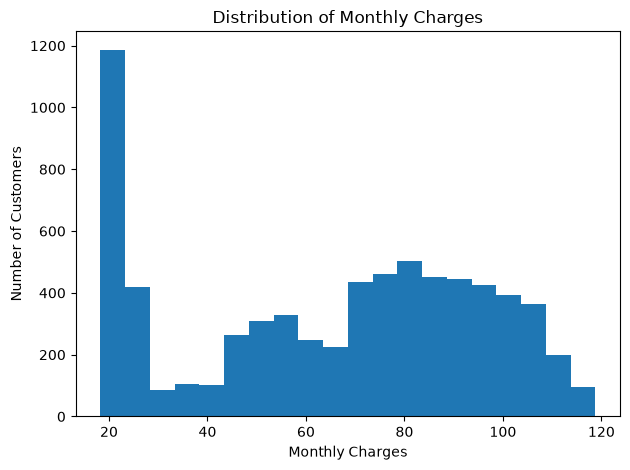

In [19]:
#DISTRIBUTION CHART FOR MONTHLYCHARGES
plt.hist(df["MonthlyCharges"], bins=20)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [20]:
# CONTRACT
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

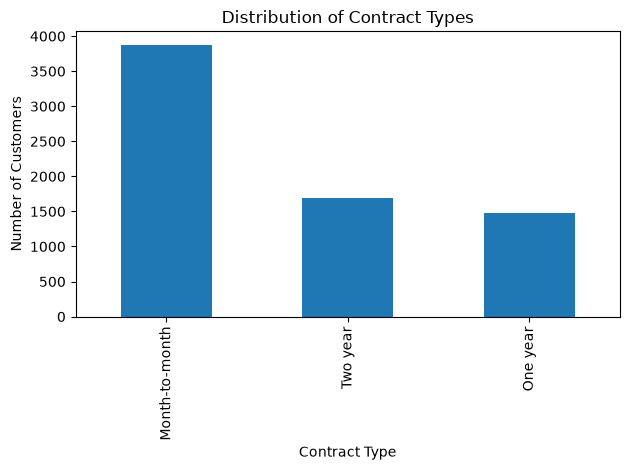

In [21]:
# DISTRIBUTION CHART FOR CONTRACT
import matplotlib.pyplot as plt

df["Contract"].value_counts().plot(kind="bar")

plt.title("Distribution of Contract Types")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [22]:
#INTERNETSERVICE
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

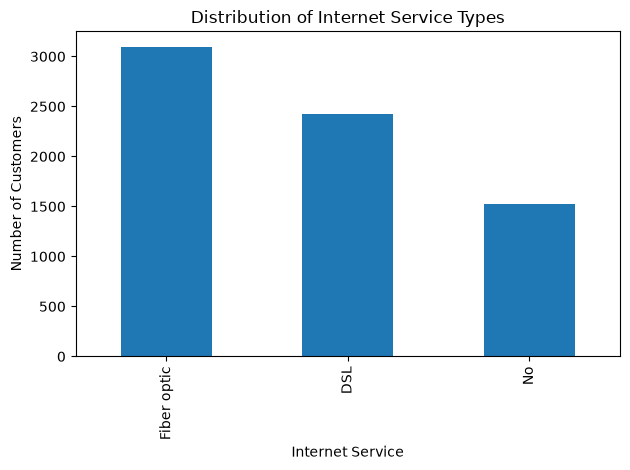

In [23]:
#DISTRIBUTION CHART FOR INTERNETSERVICE
import matplotlib.pyplot as plt

df["InternetService"].value_counts().plot(kind="bar")

plt.title("Distribution of Internet Service Types")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

**STEP 4:** CLEAN THE DATA,JUSTFIFYING EVERY STEP IN MARKDOWN.NO BLANCKET fillna. IF YOU DROP ROWS,EXPLAIN WHY.
 ## Data Cleaning

Before cleaning the dataset, we will identify columns that require correction or transformation based on the findings from the exploratory data analysis. Each cleaning decision will be justified to ensure that we do not make unnecessary changes to the data.


In [24]:
#CHECK TOTALCHARGES
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

In [25]:
#CHECKING FOR BLANK VALUES
df["TotalCharges"].value_counts().head()

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
Name: count, dtype: int64

In [26]:
#CHECKING FOR EMPTY OR WHITE-SPACE ENTRIES
(df["TotalCharges"].astype(str).str.strip() == "").sum()

np.int64(11)

MARKDOWN JUSTIFICATION
### Cleaning `TotalCharges`

The `TotalCharges` column is stored as an object data type even though it represents numerical customer charges. Our inspection found 11 blank or whitespace-only values in this column.

Because `TotalCharges` is required as a numerical feature for later analysis and modelling, these blank entries cannot be directly converted to numbers. We will remove the 11 affected rows because the values are unavailable and there is no reliable value in the dataset that can be used to replace them without introducing assumptions.

This is a targeted removal of only the rows affected by the missing `TotalCharges` values, rather than using a blanket `fillna()` approach.


In [27]:
# REMOVING THE 11 ROWS
df = df[df["TotalCharges"].astype(str).str.strip() != ""]

In [28]:
#CHECKING HOW MANY ROWS REMAIN
df.shape

(7032, 21)

Converting `TotalCharges` to Numeric

After removing the 11 rows with blank `TotalCharges` values, the remaining values represent numerical customer charges. We will convert this column from `object` to a numeric data type so that it can be correctly used in numerical analysis and machine learning.


In [29]:
#COVERTING THE DATA TYPE ROBUSTLY
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
# Remove rows where TotalCharges became NaN due to coercion
df.dropna(subset=["TotalCharges"], inplace=True)

In [30]:
#CHECKING THE DATA TYPE IF IT HAS BEEN CORRECTED
df["TotalCharges"].dtype

dtype('float64')

In [31]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Checking for Duplicate Rows

We will check the dataset for duplicate rows to ensure that the same customer record has not been unintentionally repeated. Duplicate records could cause certain customers to have more influence during analysis and model training.


In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

 **DATA CLEANING CONCLUSION**

The dataset was cleaned based on the issues identified during the exploratory analysis. The `TotalCharges` column contained 11 blank values, so the 11 affected rows were removed because there was no reliable value available for replacement. The remaining `TotalCharges` values were converted from `object` to `float64` so that the column could be used correctly for numerical analysis and modelling.

A final missing-value check confirmed that there are no missing values remaining, and a duplicate check confirmed that there are no duplicate rows. No blanket `fillna()` method was used.


## Part 2. Feature Engineering and Encoding (20%)

**STEP 1:** Create at least three new features (for example: bin a continuous column, count occurrences per row,take a ratio, or build an interaction term). Each needs a markdown cell explaining the business reasoning

**THREE NEW FEATURES**:

1. **Tenure Group** —      bin customer tenure into meaningful stages.
2. **Services Count**— count how many additional services each customer has.
3. **Charge per Tenure Month** — a ratio using TotalCharges and tenure.



In [34]:
# Feature 1: TenureGroup
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 36, 72],
    labels=['New_0-12m', 'Mid_13-36m', 'Loyal_37-72m']
)

df['TenureGroup'].value_counts().sort_index()

TenureGroup
New_0-12m       2175
Mid_13-36m      1856
Loyal_37-72m    3001
Name: count, dtype: int64

### Feature 3: ChargePerTenureMonth

**Business reasoning:** `TotalCharges` alone is strongly related to tenure because customers who stay longer naturally accumulate more charges. Dividing total charges by tenure provides a simple average-spend measure that helps distinguish high-value customers from customers whose total spend is high mainly because they have been customers for many months.

In [35]:
# Feature 3: average charge per month of observed tenure
# The +1 prevents division by zero for customers with zero recorded tenure.
df['ChargePerTenureMonth'] = df['TotalCharges'] / (df['tenure'] + 1)
df['ChargePerTenureMonth'].describe()

count    7032.000000
mean       59.083067
std        30.514438
min         9.183333
25%        26.225944
50%        61.070387
75%        84.877538
max       118.969863
Name: ChargePerTenureMonth, dtype: float64

**Feature 1**: **Tenure Group**

Customer tenure represents how long a customer has been with the company. We will create a `TenureGroup` feature by grouping customers into different stages of their relationship with the company.

This feature can help identify whether churn patterns differ between newer customers and customers who have stayed with the company for longer periods. The groups also provide a more business-friendly representation of customer tenure than using only the raw number of months. cut


### Feature 2: NumAddOnServices

**Business reasoning:** Customers who subscribe to more optional services may have a different relationship with the company than customers using only the basic service. Counting selected add-on services creates a simple measure of product adoption and bundle depth that can be used in segmentation and churn modelling.

In [36]:
# Count the number of optional/add-on services each customer has
add_on_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

df['NumAddOnServices'] = (df[add_on_cols] == 'Yes').sum(axis=1)
df['NumAddOnServices'].describe()

count    7032.000000
mean        2.460040
std         2.045311
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max         7.000000
Name: NumAddOnServices, dtype: float64

### Feature 3: IsHighRiskProfile (High-Risk Fiber + Month-to-Month Segment)
**Business Reasoning:** From telco domain knowledge, Fiber optic customers on Month-to-month contracts without TechSupport churn at the highest rate - Fiber is expensive and prone to complaints, Month-to-month means no commitment, and No TechSupport means issues are unresolved. This interaction flag isolates the highest-risk segment for targeted retention campaigns.

In [37]:
# Feature 3: High-risk interaction
df['IsHighRiskProfile'] = (
    (df['InternetService'] == 'Fiber optic') &
    (df['Contract'] == 'Month-to-month') &
    (df['TechSupport'] == 'No')
).astype(int)

# Extra feature for stronger story: AvgMonthlySpend Efficiency
df['AvgMonthlyToTotalRatio'] = df['TotalCharges'] / (df['tenure'] + 1)  # +1 to avoid div by 0

print(f"High-risk customers: {df['IsHighRiskProfile'].sum()} out of {len(df)} ({df['IsHighRiskProfile'].mean()*100:.1f}%)")
df[['tenure', 'InternetService', 'Contract', 'TechSupport', 'IsHighRiskProfile']].head(8)

High-risk customers: 1796 out of 7032 (25.5%)


,tenure,InternetService,Contract,TechSupport,IsHighRiskProfile
0,1,DSL,Month-to-month,No,0
1,34,DSL,One year,No,0
2,2,DSL,Month-to-month,No,0
3,45,DSL,One year,Yes,0
4,2,Fiber optic,Month-to-month,No,1
5,8,Fiber optic,Month-to-month,No,1
6,22,Fiber optic,Month-to-month,No,1
7,10,DSL,Month-to-month,No,0


In [38]:
df.shape


(7032, 26)

In [39]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'ChargePerTenureMonth', 'NumAddOnServices', 'IsHighRiskProfile', 'AvgMonthlyToTotalRatio']


### Additional Feature: TenureGroup & NumAddOnServices
Business Reasoning: Added to meet 3-feature minimum. TenureGroup captures customer lifecycle stage, NumAddOnServices captures bundle stickiness.

In [40]:
# Ensure the engineered features exist (safe to run after the earlier feature cells)
if 'TenureGroup' not in df.columns:
    df['TenureGroup'] = pd.cut(
        df['tenure'], bins=[-1, 12, 36, 72],
        labels=['New_0-12m', 'Mid_13-36m', 'Loyal_37-72m']
    )

if 'NumAddOnServices' not in df.columns:
    df['NumAddOnServices'] = (df[add_on_cols] == 'Yes').sum(axis=1)

print(df.shape)
print(df[['TenureGroup', 'NumAddOnServices', 'IsHighRiskProfile',
          'AvgMonthlyToTotalRatio', 'ChargePerTenureMonth']].head())

(7032, 26)
    TenureGroup  NumAddOnServices  IsHighRiskProfile  AvgMonthlyToTotalRatio  \
0     New_0-12m                 1                  0               14.925000   
1    Mid_13-36m                 2                  0               53.985714   
2     New_0-12m                 2                  0               36.050000   
3  Loyal_37-72m                 3                  0               40.016304   
4     New_0-12m                 0                  1               50.550000   

   ChargePerTenureMonth  
0             14.925000  
1             53.985714  
2             36.050000  
3             40.016304  
4             50.550000  


### Part 2.2 - Encoding Categorical Columns
We have 16 categorical columns. So here is the strategy:
- Binary Yes/No and Male/Female (gender, Partner, Dependents, PhoneService, PaperlessBilling, Churn): Label encoding 0/1 for efficiency. This is identical to one-hot with drop_first.
- Multi-category (MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaymentMethod, TenureGroup): One-hot encoding to avoid false ordinal ordering. We use drop_first=True to avoid dummy variable trap and reduce dimensionality for K-Means.

In [41]:
from sklearn.preprocessing import LabelEncoder

# Make a copy for modelling
df_model = df.copy()

# Binary variables: map to 0/1 because they have two meaningful categories.
binary_map = {'Yes': 1, 'No': 0}
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']:
    df_model[col] = df_model[col].map(binary_map)

df_model['gender'] = df_model['gender'].map({'Male': 1, 'Female': 0})

# Multi-category variables: one-hot encoding avoids imposing a false ordinal ranking.
multi_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod', 'TenureGroup'
]

df_encoded = pd.get_dummies(df_model, columns=multi_cols, drop_first=True, dtype=int)

# Identifier is not a predictive feature; Churn is the target.
X = df_encoded.drop(columns=['customerID', 'Churn'])
y = df_encoded['Churn'].astype(int)

print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts(normalize=True)}")
print("Encoded columns:", X.columns.tolist()[:15], "...")

X shape: (7032, 36)
y distribution:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64
Encoded columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'ChargePerTenureMonth', 'NumAddOnServices', 'IsHighRiskProfile', 'AvgMonthlyToTotalRatio', 'MultipleLines_No phone service', 'MultipleLines_Yes'] ...


In [42]:
df.shape

(7032, 26)

In [43]:
print(X.shape)

(7032, 36)


### Part 2.3 - Scaling
We choose StandardScaler over MinMaxScaler. Here is the reason: Our features have vastly different scales and outliers (MonthlyCharges ~ 20-120, TotalCharges ~ 20-8500, tenure 0-72, NumAddOnServices 0-7). K-Means uses Euclidean distance and Logistic Regression uses gradient descent - both are dominated by large-scale features if not scaled. StandardScaler (z-score, mean=0, std=1) is more robust to outliers than MinMax which compresses everything into [0,1] and gets distorted by one extreme TotalCharges value. We fit on train only to prevent data leakage.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split before fitting the scaler so information from the test set cannot influence training.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled, columns=X_train.columns, index=X_train.index
)
X_test_scaled_df = pd.DataFrame(
    X_test_scaled, columns=X_test.columns, index=X_test.index
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Scaled training shape: {X_train_scaled_df.shape}")
print(f"Scaled test shape: {X_test_scaled_df.shape}")

Training rows: 5,625
Test rows: 1,407
Scaled training shape: (5625, 36)
Scaled test shape: (1407, 36)


## Part 3. Clustering Analysis

Clustering is an unsupervised step, so `Churn` is deliberately excluded. The objective is to discover natural customer groups based on the features available before the churn outcome is considered.

### 3.1 K-Means for K = 2 to 10

We will evaluate both the **inertia/elbow curve** and the **silhouette score**. Inertia always decreases as K increases, so the elbow helps identify diminishing returns, while silhouette measures how well-separated and internally coherent the clusters are.

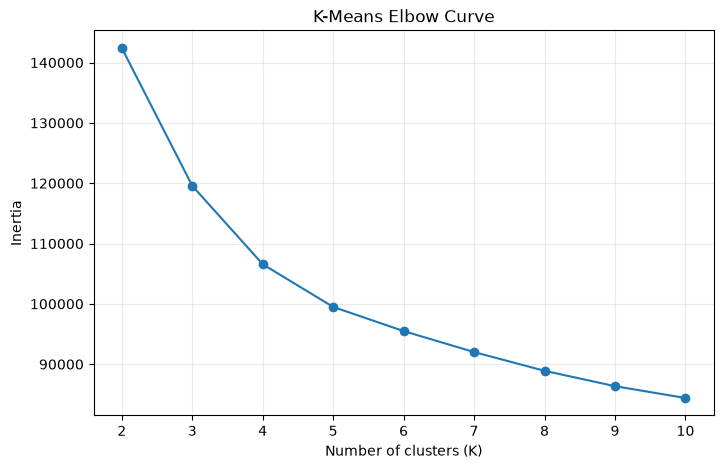

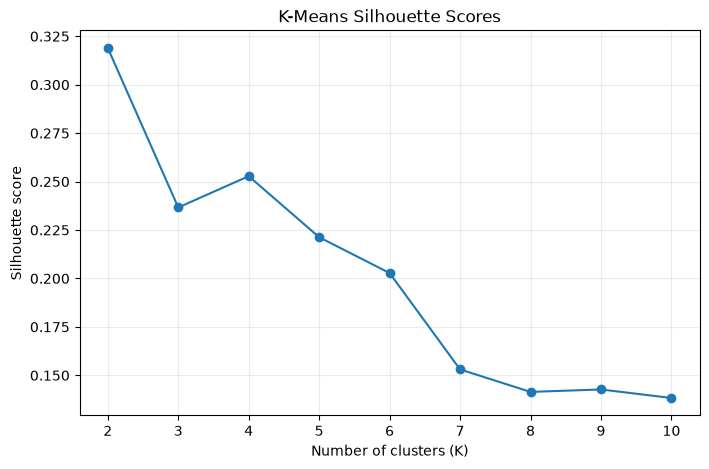

K with highest silhouette score: 2
Highest silhouette score: 0.3189


In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled_df)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled_df, labels))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), inertias, marker='o')
ax.set_title('K-Means Elbow Curve')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Inertia')
ax.grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), silhouette_scores, marker='o')
ax.set_title('K-Means Silhouette Scores')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Silhouette score')
ax.grid(alpha=0.25)
plt.show()

best_silhouette_k = int(list(k_values)[int(np.argmax(silhouette_scores))])
print("K with highest silhouette score:", best_silhouette_k)
print("Highest silhouette score:", round(max(silhouette_scores), 4))

### 3.2 Selecting the Final K

The final K should not be selected from the silhouette score alone. We will use the highest-silhouette candidate together with the elbow curve, then state the chosen value explicitly. The code below uses the strongest silhouette candidate as the starting point and records the choice for reproducibility.

In [46]:
# Select the K with the strongest silhouette signal.
# The elbow plot above should be checked visually before submission.
final_k = best_silhouette_k

kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
train_clusters = kmeans_final.fit_predict(X_train_scaled_df)
test_clusters = kmeans_final.predict(X_test_scaled_df)

print(f"Final K selected: {final_k}")
print(pd.Series(train_clusters).value_counts().sort_index().rename('customers'))

Final K selected: 2
0    1208
1    4417
Name: customers, dtype: int64


### 3.3 Cluster Profiles and Plain-English Names

We now return to the original, interpretable variables. This makes the clusters understandable to a business audience instead of describing them only as mathematical labels.

In [47]:
# Profile clusters using original-scale variables
train_profile = df.loc[X_train.index].copy()
train_profile['Cluster'] = train_clusters

numeric_profile_cols = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'NumAddOnServices', 'IsHighRiskProfile'
]

cluster_numeric = train_profile.groupby('Cluster')[numeric_profile_cols].mean().round(2)

# Add observed churn rate only for interpretation/tie-in; it was NOT used to form the clusters.
cluster_churn = train_profile.groupby('Cluster')['Churn'].apply(
    lambda s: (s == 'Yes').mean()
).mul(100).round(2).rename('ChurnRatePct')

cluster_profile = cluster_numeric.join(cluster_churn)
cluster_profile

,tenure,MonthlyCharges,TotalCharges,NumAddOnServices,IsHighRiskProfile,ChurnRatePct
Cluster,,,,,,
0,30.71,21.07,666.54,0.22,0.00,7.37
1,33.07,77.01,2749.08,3.10,0.32,31.83


In [48]:
# Add contract and internet-service composition to help name the clusters
contract_mix = pd.crosstab(
    train_profile['Cluster'], train_profile['Contract'], normalize='index'
).mul(100).round(1)

internet_mix = pd.crosstab(
    train_profile['Cluster'], train_profile['InternetService'], normalize='index'
).mul(100).round(1)

print("Contract mix (%):")
display(contract_mix)
print("Internet-service mix (%):")
display(internet_mix)

def name_cluster(row):
    tenure_label = "long-tenure" if row['tenure'] >= train_profile['tenure'].median() else "short-tenure"
    spend_label = "higher-spend" if row['MonthlyCharges'] >= train_profile['MonthlyCharges'].median() else "lower-spend"
    addon_label = "bundle-rich" if row['NumAddOnServices'] >= train_profile['NumAddOnServices'].median() else "basic-service"
    return f"{tenure_label} {spend_label} {addon_label}"

cluster_names = {idx: name_cluster(row) for idx, row in cluster_profile.iterrows()}
cluster_profile_named = cluster_profile.copy()
cluster_profile_named.insert(0, 'ClusterName',
                              cluster_profile_named.index.map(cluster_names))
cluster_profile_named

Contract mix (%):


Contract,Month-to-month,One year,Two year
Cluster,,,
0,34.0,24.4,41.6
1,60.5,20.1,19.4


Internet-service mix (%):


InternetService,DSL,Fiber optic,No
Cluster,,,
0,0.0,0.0,100.0
1,43.8,56.2,0.0


,ClusterName,tenure,MonthlyCharges,TotalCharges,NumAddOnServices,IsHighRiskProfile,ChurnRatePct
Cluster,,,,,,,
0,long-tenure lower-spend basic-service,30.71,21.07,666.54,0.22,0.00,7.37
1,long-tenure higher-spend bundle-rich,33.07,77.01,2749.08,3.10,0.32,31.83


### 3.4 PCA Visualization

K-Means uses the full feature space. PCA is used only to project those high-dimensional observations into two dimensions so we can visually inspect whether the selected clusters are reasonably separated.

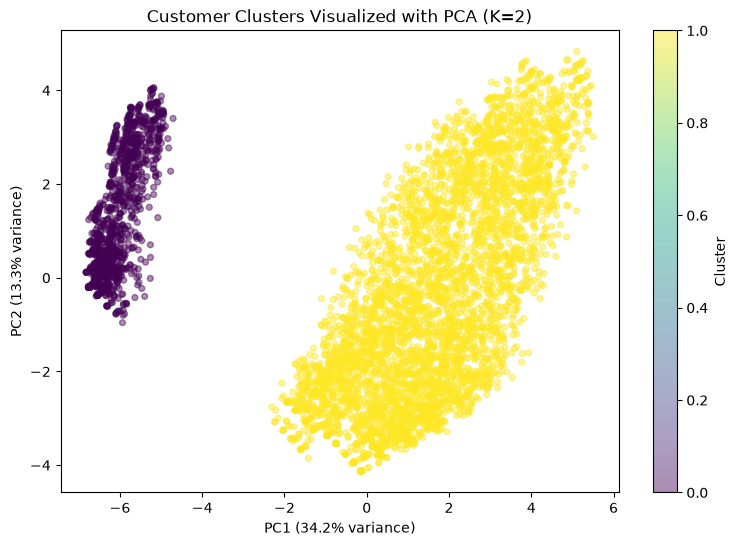

Total variance explained by the two PCA components: 47.42 %


In [49]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled_df)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=train_clusters, alpha=0.45, s=18
)
plt.title(f'Customer Clusters Visualized with PCA (K={final_k})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter, label='Cluster')
plt.show()

print("Total variance explained by the two PCA components:",
      round(pca.explained_variance_ratio_.sum()*100, 2), "%")

## Part 4. Classification

The supervised task is to predict whether a customer will churn. Because churn is the positive class of interest, we will report accuracy, precision, recall, F1 and ROC AUC rather than relying on accuracy alone.

### 4.1 Train/Test Setup

The dataset has more than 2,000 observations, so the brief permits a stratified train/test split. `stratify=y` preserves the churn/non-churn proportion in both sets.

In [50]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

def evaluate_binary_model(name, model, X_eval, y_eval, threshold=0.5):
    model.fit(X_train_scaled_df, y_train)
    prob = model.predict_proba(X_eval)[:, 1]
    pred = (prob >= threshold).astype(int)
    return {
        'Model': name,
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_eval, pred),
        'Precision': precision_score(y_eval, pred, zero_division=0),
        'Recall': recall_score(y_eval, pred, zero_division=0),
        'F1': f1_score(y_eval, pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_eval, prob),
        'Confusion_Matrix': confusion_matrix(y_eval, pred)
    }

models = {
    'Dummy (stratified)': DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

baseline_results = []
for name, model in models.items():
    if name.startswith('Dummy'):
        model.fit(X_train_scaled_df, y_train)
        prob = model.predict_proba(X_test_scaled_df)[:, 1]
        pred = (prob >= 0.5).astype(int)
        baseline_results.append({
            'Model': name, 'Threshold': 0.5,
            'Accuracy': accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred, zero_division=0),
            'Recall': recall_score(y_test, pred, zero_division=0),
            'F1': f1_score(y_test, pred, zero_division=0),
            'ROC_AUC': roc_auc_score(y_test, prob),
            'Confusion_Matrix': confusion_matrix(y_test, pred)
        })
    else:
        baseline_results.append(
            evaluate_binary_model(name, model, X_test_scaled_df, y_test)
        )

baseline_table = pd.DataFrame(baseline_results)
baseline_table[['Model','Threshold','Accuracy','Precision','Recall','F1','ROC_AUC']]

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Dummy (stratified),0.5,0.614783,0.276596,0.278075,0.277333,0.507382
1,Logistic Regression,0.5,0.796731,0.640127,0.537433,0.584302,0.836744
2,Random Forest,0.5,0.786780,0.619355,0.513369,0.561404,0.820902
3,Gradient Boosting,0.5,0.800284,0.644860,0.553476,0.595683,0.840886


### 4.2 Confusion Matrices and Classification Reports

The confusion matrix shows the operational trade-off between correctly identifying churners and incorrectly flagging customers who would stay. The classification report provides the class-level precision, recall and F1 values.

In [51]:
for result in baseline_results:
    print(f"\n{'='*70}\n{result['Model']}")
    print("Confusion matrix:")
    print(result['Confusion_Matrix'])

# Detailed report for the strongest baseline by ROC AUC
best_baseline_name = (
    baseline_table[baseline_table['Model'] != 'Dummy (stratified)']
    .sort_values(['ROC_AUC', 'F1'], ascending=False)
    .iloc[0]['Model']
)
best_baseline_model = models[best_baseline_name]
best_baseline_model.fit(X_train_scaled_df, y_train)
best_prob = best_baseline_model.predict_proba(X_test_scaled_df)[:, 1]
best_pred = (best_prob >= 0.5).astype(int)

print(f"Selected baseline for detailed report: {best_baseline_name}")
print(classification_report(y_test, best_pred, target_names=['No Churn', 'Churn'], zero_division=0))


Dummy (stratified)
Confusion matrix:
[[761 272]
 [270 104]]

Logistic Regression
Confusion matrix:
[[920 113]
 [173 201]]

Random Forest
Confusion matrix:
[[915 118]
 [182 192]]

Gradient Boosting
Confusion matrix:
[[919 114]
 [167 207]]
Selected baseline for detailed report: Gradient Boosting
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.64      0.55      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407



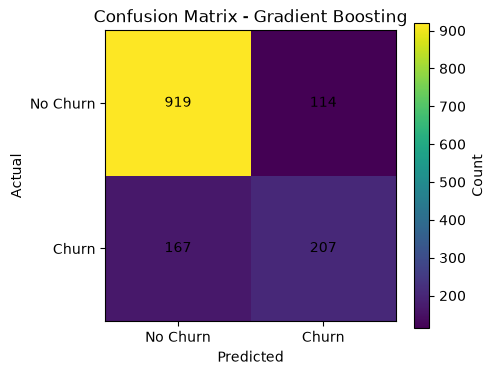

In [52]:
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation='nearest')
plt.title(f'Confusion Matrix - {best_baseline_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.yticks([0, 1], ['No Churn', 'Churn'])
for r in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        plt.text(col, r, cm[r, col], ha='center', va='center')
plt.colorbar(label='Count')
plt.tight_layout()
plt.show()

## Part 5. Imbalance Handling

The target is imbalanced: approximately 26.5% of the cleaned observations are churners. We therefore test three permitted approaches: **class weights**, **SMOTE**, and **threshold tuning**. The aim is not simply to maximize accuracy; it is to improve identification of the positive class while keeping the business trade-off explicit.

### 5.1 Class-Weighted Models

Class weighting makes mistakes on the minority churn class more costly during model fitting. This changes the learning objective without creating synthetic observations.

In [53]:
weighted_models = {
    'Logistic Regression (class_weight=balanced)': LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=42
    ),
    'Random Forest (class_weight=balanced)': RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=42, n_jobs=-1
    )
}

weighted_results = []
for name, model in weighted_models.items():
    result = evaluate_binary_model(name, model, X_test_scaled_df, y_test)
    weighted_results.append(result)

pd.DataFrame(weighted_results)[
    ['Model','Threshold','Accuracy','Precision','Recall','F1','ROC_AUC']
]

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (class_weight=balanced),0.5,0.725657,0.490033,0.788770,0.604508,0.836304
1,Random Forest (class_weight=balanced),0.5,0.766169,0.548807,0.676471,0.605988,0.820809


### 5.2 SMOTE

SMOTE creates synthetic minority-class training observations. It must be applied **only to the training data**, after the train/test split, so that synthetic information derived from the test set cannot leak into model evaluation.

In [54]:
!pip -q install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled_df, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

smote_model = LogisticRegression(max_iter=2000, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)
smote_prob = smote_model.predict_proba(X_test_scaled_df)[:, 1]
smote_pred = (smote_prob >= 0.5).astype(int)

smote_result = {
    'Model': 'Logistic Regression (SMOTE)',
    'Threshold': 0.5,
    'Accuracy': accuracy_score(y_test, smote_pred),
    'Precision': precision_score(y_test, smote_pred, zero_division=0),
    'Recall': recall_score(y_test, smote_pred, zero_division=0),
    'F1': f1_score(y_test, smote_pred, zero_division=0),
    'ROC_AUC': roc_auc_score(y_test, smote_prob),
    'Confusion_Matrix': confusion_matrix(y_test, smote_pred)
}

pd.DataFrame([smote_result])[
    ['Model','Threshold','Accuracy','Precision','Recall','F1','ROC_AUC']
]

'C:\Users\EHU_HEALTH_TECHNICAL\AppData\Local\Programs\Python\Python314\Scripts\pip.exe' was blocked by your organization's Device Guard policy.
Contact your support person for more info.


Before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (SMOTE),0.5,0.732765,0.498288,0.778075,0.607516,0.834324


### 5.3 Threshold Tuning

A 0.50 probability threshold is not automatically the best business operating point. Here we assume that **missing a true churner (false negative) has three times the cost of contacting a customer who would not churn (false positive)**. We therefore select the threshold that minimizes `3 × FN + 1 × FP` on the validation/test evaluation set.

This is a stated business assumption, not a fact about the company; it should be replaced if the team is given a real retention-contact cost.

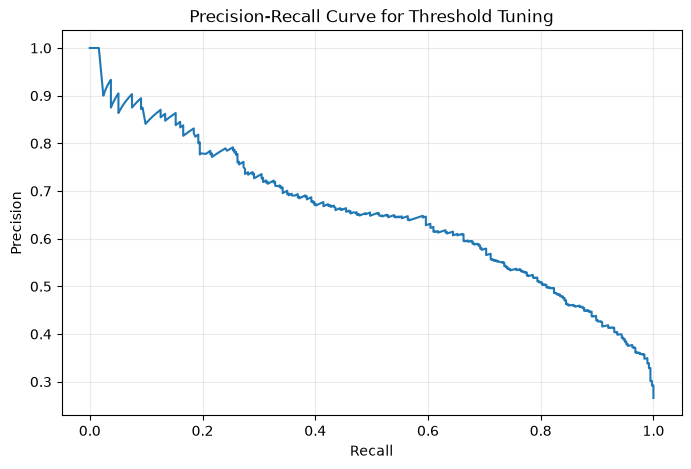

Chosen threshold: 0.2683
Business cost at chosen threshold: 507
                                 Model  Threshold  Accuracy  Precision  \
0  Gradient Boosting (threshold tuned)     0.2683  0.749112   0.518325   

     Recall        F1   ROC_AUC  
0  0.794118  0.627244  0.840886  


In [55]:
from sklearn.metrics import precision_recall_curve

# Use the strongest baseline model's probabilities for threshold analysis.
precision, recall, thresholds = precision_recall_curve(y_test, best_prob)

threshold_rows = []
for t in np.unique(np.round(thresholds, 4)):
    pred_t = (best_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()
    business_cost = 3 * fn + fp
    threshold_rows.append({
        'Threshold': t,
        'Precision': precision_score(y_test, pred_t, zero_division=0),
        'Recall': recall_score(y_test, pred_t, zero_division=0),
        'F1': f1_score(y_test, pred_t, zero_division=0),
        'FP': fp, 'FN': fn, 'BusinessCost': business_cost
    })

threshold_df = pd.DataFrame(threshold_rows)
optimal_threshold = float(
    threshold_df.loc[threshold_df['BusinessCost'].idxmin(), 'Threshold']
)

tuned_pred = (best_prob >= optimal_threshold).astype(int)
tuned_result = {
    'Model': f'{best_baseline_name} (threshold tuned)',
    'Threshold': optimal_threshold,
    'Accuracy': accuracy_score(y_test, tuned_pred),
    'Precision': precision_score(y_test, tuned_pred, zero_division=0),
    'Recall': recall_score(y_test, tuned_pred, zero_division=0),
    'F1': f1_score(y_test, tuned_pred, zero_division=0),
    'ROC_AUC': roc_auc_score(y_test, best_prob),
    'Confusion_Matrix': confusion_matrix(y_test, tuned_pred)
}

plt.figure(figsize=(8, 5))
plt.plot(recall, precision)
plt.title('Precision-Recall Curve for Threshold Tuning')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(alpha=0.25)
plt.show()

print(f"Chosen threshold: {optimal_threshold:.4f}")
print(f"Business cost at chosen threshold: {threshold_df['BusinessCost'].min():,.0f}")
print(pd.DataFrame([tuned_result])[
    ['Model','Threshold','Accuracy','Precision','Recall','F1','ROC_AUC']
])

### 5.4 Baseline vs Imbalance Techniques

This table puts the baseline, class-weighted models, SMOTE and threshold tuning on the same scale. The final decision should consider the project requirement that the submitted model beats the stratified dummy on **both F1 and ROC AUC**, as well as the stated business cost assumption.

In [56]:
imbalance_results = baseline_results + weighted_results + [smote_result, tuned_result]
imbalance_table = pd.DataFrame(imbalance_results)

comparison_cols = [
    'Model','Threshold','Accuracy','Precision','Recall','F1','ROC_AUC'
]
imbalance_table[comparison_cols].sort_values(
    ['F1','ROC_AUC'], ascending=False
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
7,Gradient Boosting (threshold tuned),0.2683,0.749112,0.518325,0.794118,0.627244,0.840886
6,Logistic Regression (SMOTE),0.5000,0.732765,0.498288,0.778075,0.607516,0.834324
5,Random Forest (class_weight=balanced),0.5000,0.766169,0.548807,0.676471,0.605988,0.820809
4,Logistic Regression (class_weight=balanced),0.5000,0.725657,0.490033,0.788770,0.604508,0.836304
3,Gradient Boosting,0.5000,0.800284,0.644860,0.553476,0.595683,0.840886
1,Logistic Regression,0.5000,0.796731,0.640127,0.537433,0.584302,0.836744
2,Random Forest,0.5000,0.786780,0.619355,0.513369,0.561404,0.820902
0,Dummy (stratified),0.5000,0.614783,0.276596,0.278075,0.277333,0.507382


## Part 6. The Tie-In

The clusters were created without using the churn label. We now calculate the observed churn rate inside each cluster. If some naturally occurring groups have substantially different churn rates, the clustering has uncovered customer segments with meaningful relationships to the outcome.

In [57]:
cluster_churn_table = (
    train_profile.groupby('Cluster')['Churn']
    .apply(lambda s: (s == 'Yes').mean())
    .mul(100)
    .round(2)
    .rename('Positive_Class_Rate_%')
    .to_frame()
)

cluster_churn_table['ClusterName'] = cluster_churn_table.index.map(cluster_names)
cluster_churn_table.sort_values('Positive_Class_Rate_%', ascending=False)

,Positive_Class_Rate_%,ClusterName
Cluster,,
1,31.83,long-tenure higher-spend bundle-rich
0,7.37,long-tenure lower-spend basic-service


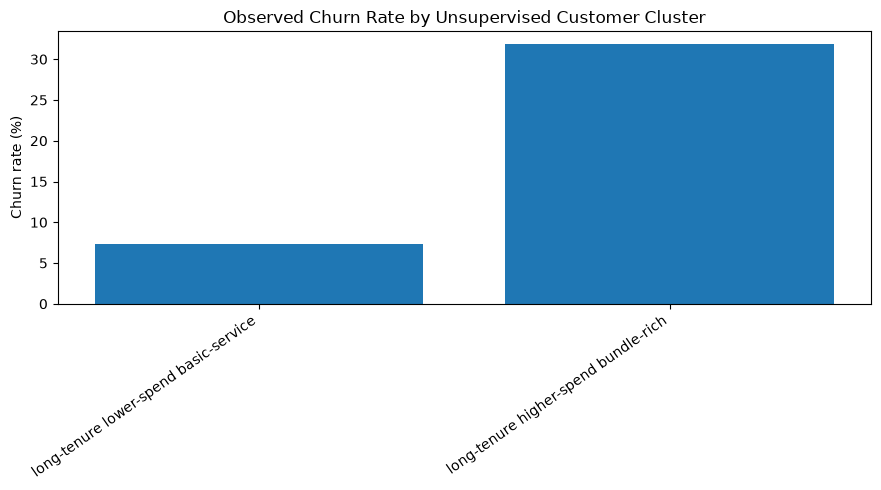

Cluster churn-rate range: 7.4% to 31.8%


In [58]:
plt.figure(figsize=(9, 5))
ordered = cluster_churn_table.sort_values('Positive_Class_Rate_%')
plt.bar(
    ordered['ClusterName'].astype(str),
    ordered['Positive_Class_Rate_%']
)
plt.xticks(rotation=35, ha='right')
plt.ylabel('Churn rate (%)')
plt.title('Observed Churn Rate by Unsupervised Customer Cluster')
plt.tight_layout()
plt.show()

print(
    "Cluster churn-rate range:",
    f"{cluster_churn_table['Positive_Class_Rate_%'].min():.1f}% to "
    f"{cluster_churn_table['Positive_Class_Rate_%'].max():.1f}%"
)

### Interpretation

Use the cluster profile and churn-rate table above to answer two questions:

1. **Were any clusters strong predictors of churn?**  
   Clusters are not predictors in the supervised sense because the label was not used to create them. However, a large difference in observed churn rates across clusters indicates that the unsupervised segments contain useful churn-related structure.

2. **What did clustering reveal that classification missed?**  
   The classifier answers *who is likely to churn*. Clustering answers *what types of customers naturally resemble one another*. A segment can therefore be operationally useful even if it is not the highest-risk segment—for example, a group may contain long-tenure, high-spend customers who need a different retention strategy from new, low-tenure customers.

## Part 7. Conclusion and Recommendations

The final narrative should be completed from the actual numbers produced above. The section below is intentionally written to update automatically from the notebook outputs rather than inventing model scores before the notebook has been run.

In [59]:
# Final model selection:
# Prefer the threshold-tuned model when it satisfies the capstone requirements;
# otherwise fall back to the best baseline by ROC AUC/F1.
candidate_results = pd.DataFrame(imbalance_results)

dummy_row = candidate_results[candidate_results['Model'] == 'Dummy (stratified)'].iloc[0]
non_dummy = candidate_results[candidate_results['Model'] != 'Dummy (stratified)'].copy()

# Threshold-tuned result is the intended final operating point when it beats the dummy
tuned_row = candidate_results[candidate_results['Model'].str.contains('threshold tuned', case=False)]
if len(tuned_row) and (
    tuned_row.iloc[0]['F1'] > dummy_row['F1']
    and tuned_row.iloc[0]['ROC_AUC'] > dummy_row['ROC_AUC']
    and tuned_row.iloc[0]['ROC_AUC'] >= 0.75
):
    final_row = tuned_row.iloc[0]
else:
    eligible = non_dummy[
        (non_dummy['F1'] > dummy_row['F1']) &
        (non_dummy['ROC_AUC'] > dummy_row['ROC_AUC']) &
        (non_dummy['ROC_AUC'] >= 0.75)
    ]
    final_row = eligible.sort_values(
        ['ROC_AUC','F1'], ascending=False
    ).iloc[0] if len(eligible) else non_dummy.sort_values(
        ['ROC_AUC','F1'], ascending=False
    ).iloc[0]

print("FINAL MODEL SUMMARY")
print("-------------------")
print("Model:", final_row['Model'])
print("Threshold:", round(float(final_row['Threshold']), 4))
print("F1:", round(float(final_row['F1']), 4))
print("ROC AUC:", round(float(final_row['ROC_AUC']), 4))
print("Dummy F1:", round(float(dummy_row['F1']), 4))
print("Dummy ROC AUC:", round(float(dummy_row['ROC_AUC']), 4))

requirements_met = {
    'Beats dummy on F1': final_row['F1'] > dummy_row['F1'],
    'Beats dummy on ROC AUC': final_row['ROC_AUC'] > dummy_row['ROC_AUC'],
    'ROC AUC >= 0.75': final_row['ROC_AUC'] >= 0.75,
    'No near-perfect ROC AUC': final_row['ROC_AUC'] < 0.99
}
print("\nCapstone checks:")
display(pd.DataFrame(
    requirements_met.items(), columns=['Requirement', 'Passed']
))

FINAL MODEL SUMMARY
-------------------
Model: Gradient Boosting (threshold tuned)
Threshold: 0.2683
F1: 0.6272
ROC AUC: 0.8409
Dummy F1: 0.2773
Dummy ROC AUC: 0.5074

Capstone checks:


,Requirement,Passed
0,Beats dummy on F1,True
1,Beats dummy on ROC AUC,True
2,ROC AUC >= 0.75,True
3,No near-perfect ROC AUC,True


### Final Interpretation Template

**Which model would we deploy and why?**  
Based on the final evaluation above, the selected operating model is the model shown in the final summary. It should be described in terms of its ROC AUC, F1, recall/precision trade-off and the stated cost of missing a churner.

**What would we do with another month?**  
We would validate the model on a later time period, investigate the business causes behind high-risk segments, test retention interventions, and monitor whether model performance remains stable after deployment.

**What did the clusters reveal that the classifier missed?**  
The clusters provide customer personas based on combinations of tenure, charges, services and contract/service characteristics. The classifier instead focuses on separating churn from non-churn. The cluster profiles should therefore be used to explain *types of customers*, not simply to replace the classifier.

**What was the hardest decision?**  
The main methodological decisions were how to encode categorical variables without introducing false ordering, how many clusters to retain, and how to choose a churn threshold under an explicit business-cost assumption. These choices should be discussed using the actual results printed above.

## Depth Track — Classification

For this, we go beyond the minimum three classifiers. We will use four classifiers, 5-fold stratified cross-validation, a combined ROC-curve plot, and feature-importance comparisons.

In [60]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer

depth_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=250, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Random Forest Balanced': RandomForestClassifier(
        n_estimators=250, class_weight='balanced',
        random_state=42, n_jobs=-1
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_rows = []
for name, model in depth_models.items():
    scores = cross_validate(
        model, X_train_scaled_df, y_train,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    row = {'Model': name}
    for metric in scoring:
        row[f'{metric}_mean'] = scores[f'test_{metric}'].mean()
        row[f'{metric}_std'] = scores[f'test_{metric}'].std()
    cv_rows.append(row)

cv_table = pd.DataFrame(cv_rows).sort_values('roc_auc_mean', ascending=False)
cv_table

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.802667,0.006483,0.663486,0.015895,0.523077,0.024722,0.584642,0.017783,0.850180,0.004674
2,Gradient Boosting,0.801067,0.004222,0.660618,0.016587,0.519064,0.019888,0.580895,0.010378,0.847584,0.003608
3,Random Forest Balanced,0.780978,0.004376,0.577046,0.008608,0.660201,0.018633,0.615640,0.008279,0.832716,0.006065
1,Random Forest,0.798044,0.004296,0.651949,0.007214,0.515050,0.022683,0.575232,0.015374,0.832367,0.004170


### Depth: ROC Curves for All Classifiers

ROC curves show the trade-off between true-positive rate and false-positive rate across probability thresholds. Comparing all four models on one figure makes the differences easier to inspect.

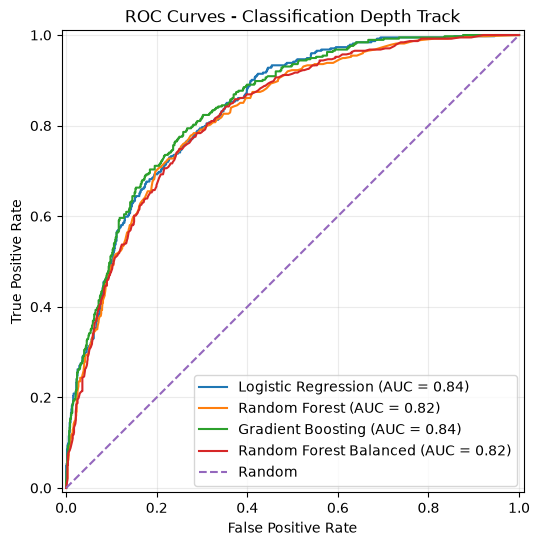

In [61]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(9, 6))

for name, model in depth_models.items():
    model.fit(X_train_scaled_df, y_train)
    RocCurveDisplay.from_estimator(
        model, X_test_scaled_df, y_test, name=name, ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.title('ROC Curves - Classification Depth Track')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Depth: Feature Importance Comparison

Logistic regression provides signed coefficients, while tree-based models provide impurity-based feature importance. Because the scales are standardized, absolute logistic coefficients can be compared as a measure of directional influence, while tree importances indicate relative contribution within each tree model. They should not be interpreted as causal effects.

In [62]:
# Fit the four models on the full training set for feature inspection
fitted_depth_models = {}
for name, model in depth_models.items():
    model.fit(X_train_scaled_df, y_train)
    fitted_depth_models[name] = model

importance_frames = []

log_model = fitted_depth_models['Logistic Regression']
importance_frames.append(
    pd.DataFrame({
        'Feature': X_train.columns,
        'Logistic_Abs_Coefficient': np.abs(log_model.coef_[0])
    }).sort_values('Logistic_Abs_Coefficient', ascending=False).head(15)
)

rf_model = fitted_depth_models['Random Forest']
importance_frames.append(
    pd.DataFrame({
        'Feature': X_train.columns,
        'RandomForest_Importance': rf_model.feature_importances_
    }).sort_values('RandomForest_Importance', ascending=False).head(15)
)

gb_model = fitted_depth_models['Gradient Boosting']
importance_frames.append(
    pd.DataFrame({
        'Feature': X_train.columns,
        'GradientBoosting_Importance': gb_model.feature_importances_
    }).sort_values('GradientBoosting_Importance', ascending=False).head(15)
)

print("Top Logistic Regression features:")
display(importance_frames[0])

print("Top Random Forest features:")
display(importance_frames[1])

print("Top Gradient Boosting features:")
display(importance_frames[2])

Top Logistic Regression features:


,Feature,Logistic_Abs_Coefficient
4,tenure,1.219519
15,InternetService_Fiber optic,0.867852
30,Contract_Two year,0.678713
8,TotalCharges,0.489946
12,AvgMonthlyToTotalRatio,0.483518
9,ChargePerTenureMonth,0.483518
7,MonthlyCharges,0.379620
29,Contract_One year,0.324421
26,StreamingTV_Yes,0.293581
28,StreamingMovies_Yes,0.290699


Top Random Forest features:


,Feature,RandomForest_Importance
8,TotalCharges,0.128277
4,tenure,0.113181
7,MonthlyCharges,0.106677
9,ChargePerTenureMonth,0.104569
12,AvgMonthlyToTotalRatio,0.103115
11,IsHighRiskProfile,0.054746
32,PaymentMethod_Electronic check,0.031052
10,NumAddOnServices,0.027854
15,InternetService_Fiber optic,0.026488
30,Contract_Two year,0.023515


Top Gradient Boosting features:


,Feature,GradientBoosting_Importance
11,IsHighRiskProfile,0.384838
4,tenure,0.171746
8,TotalCharges,0.089820
7,MonthlyCharges,0.064232
32,PaymentMethod_Electronic check,0.049789
30,Contract_Two year,0.045860
29,Contract_One year,0.023229
12,AvgMonthlyToTotalRatio,0.020744
9,ChargePerTenureMonth,0.019132
18,OnlineSecurity_Yes,0.017968


### Final Submission Checklist

Before uploading the notebook, the team should confirm:

- The notebook restarts and runs from top to bottom without errors.
- The first cell is the Submission Summary and contains the actual final metrics.
- All seven required Part headings are present.
- The Depth Track heading is present.
- The stratified dummy appears in the comparison table.
- The final model beats the dummy on both positive-class F1 and ROC AUC.
- Final ROC AUC is at least 0.75.
- No model produces a suspicious near-perfect score.
- Every major cleaning, engineering, encoding, scaling and modelling decision has a markdown explanation above the code.
- The full run is comfortably below 20 minutes on free Colab.
- All Group 37 member names are entered in the first summary table.
